<a href="https://colab.research.google.com/github/clusterZX98/NLP-natural-language-processing-/blob/main/NLP_Advance_topic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# One HOT Encoding in NLP

In [ ]:
# import liabrary
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Define corpus
corpus = [
"The quick brown fox jumps over the lazy dog",
"The dog chased the fox",
"The fox is quick and smart"
]
corpus

['The quick brown fox jumps over the lazy dog',
 'The dog chased the fox',
 'The fox is quick and smart']

In [ ]:
# preprocess text
def preprocess(corpus):
  text = corpus.lower()
  corpus = text.translate(str.maketrans('', '', string.punctuation))
  return corpus.split()

tokenize_text = [preprocess(text) for text in corpus]
print(tokenize_text)

[['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog'], ['the', 'dog', 'chased', 'the', 'fox'], ['the', 'fox', 'is', 'quick', 'and', 'smart']]


In [ ]:
# build vocabulary
vocabulary = sorted(set([word for sentence in tokenize_text for word in sentence]))
index = {word: index for index, word in enumerate(vocabulary)}
print(vocabulary)
print(index)

['and', 'brown', 'chased', 'dog', 'fox', 'is', 'jumps', 'lazy', 'over', 'quick', 'smart', 'the']
{'and': 0, 'brown': 1, 'chased': 2, 'dog': 3, 'fox': 4, 'is': 5, 'jumps': 6, 'lazy': 7, 'over': 8, 'quick': 9, 'smart': 10, 'the': 11}


In [ ]:
# one hot encode sentence
def encode (sentence,index):
  vocab_size = len(index)
  encode_sentence =[]
  for word in sentence:
    vector = np.zeros(vocab_size,dtype = int)
    vector[index[word]] = 1
    encode_sentence.append(vector)
  return np.array(encode_sentence)


encoded_vector = encode(tokenize_text[0],index)
print(encoded_vector)

[[0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0]]


In [ ]:
# display output
print("Vocabulary:")
print(vocabulary)

print("\nOne-Hot Encoded Vectors (First Sentence):")
for word, vector in zip(tokenize_text[0], encoded_vector):
    print(f"{word}: {vector}")

Vocabulary:
['and', 'brown', 'chased', 'dog', 'fox', 'is', 'jumps', 'lazy', 'over', 'quick', 'smart', 'the']

One-Hot Encoded Vectors (First Sentence):
the: [0 0 0 0 0 0 0 0 0 0 0 1]
quick: [0 0 0 0 0 0 0 0 0 1 0 0]
brown: [0 1 0 0 0 0 0 0 0 0 0 0]
fox: [0 0 0 0 1 0 0 0 0 0 0 0]
jumps: [0 0 0 0 0 0 1 0 0 0 0 0]
over: [0 0 0 0 0 0 0 0 1 0 0 0]
the: [0 0 0 0 0 0 0 0 0 0 0 1]
lazy: [0 0 0 0 0 0 0 1 0 0 0 0]
dog: [0 0 0 1 0 0 0 0 0 0 0 0]


In [ ]:
# easy way to perfrom one hot encoding by using Scikit-Learn
from sklearn.preprocessing import OneHotEncoder
import numpy as np

words = np.array([
    ['cat'],
    ['dog'],
    ['fish']
])

encoder = OneHotEncoder()

result = encoder.fit_transform(words)

print(result.toarray())

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


# BOW (BAG OF WORDS)

In [ ]:
# import liabraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
text = """Beans. I was trying to explain to somebody as we were
flying in, that's corn.
         That's beans. And they were very impressed at my
agricultural knowledge.
         Please give it up for Amaury once again for that
outstanding introduction.
         I have a bunch of good friends here today, including
somebody who I served with,
         who is one of the finest senators in the country, and
we're lucky to have him,
         your Senator, Dick Durbin is here. I also noticed, by
the way,
         former Governor Edgar here, who I haven't seen in a
long time, and
         somehow he has not aged and I have. And it's great to
see you, Governor.
         I want to thank President Killeen and everybody at the
U of I System for
         making it possible for me to be here today. And I am
deeply honored at the Paul
         Douglas Award that is being given to me. He is somebody
who set the path for so
         much outstanding public service here in Illinois. Now,
I want to start by
         addressing the elephant in the room. I know people are
still wondering why
         I didn't speak at the commencement."""


In [ ]:
dataset = nltk.sent_tokenize(text)
dataset

['Beans.',
 "I was trying to explain to somebody as we were\nflying in, that's corn.",
 "That's beans.",
 'And they were very impressed at my\nagricultural knowledge.',
 'Please give it up for Amaury once again for that\noutstanding introduction.',
 "I have a bunch of good friends here today, including\nsomebody who I served with,\n         who is one of the finest senators in the country, and\nwe're lucky to have him,\n         your Senator, Dick Durbin is here.",
 "I also noticed, by\nthe way,\n         former Governor Edgar here, who I haven't seen in a\nlong time, and\n         somehow he has not aged and I have.",
 "And it's great to\nsee you, Governor.",
 'I want to thank President Killeen and everybody at the\nU of I System for\n         making it possible for me to be here today.',
 'And I am\ndeeply honored at the Paul\n         Douglas Award that is being given to me.',
 'He is somebody\nwho set the path for so\n         much outstanding public service here in Illinois.',
 'N

In [ ]:
for i in range(len(dataset)):
  dataset[i] = dataset[i].lower()
  dataset[i] = re.sub(r'\W', ' ', dataset[i])
  dataset[i] = re.sub(r'\s+', ' ', dataset[i])

In [ ]:
for i, sentence in enumerate(dataset):
  print(f"Sentence {i+1}: {sentence}")

Sentence 1: beans 
Sentence 2: i was trying to explain to somebody as we were flying in that s corn 
Sentence 3: that s beans 
Sentence 4: and they were very impressed at my agricultural knowledge 
Sentence 5: please give it up for amaury once again for that outstanding introduction 
Sentence 6: i have a bunch of good friends here today including somebody who i served with who is one of the finest senators in the country and we re lucky to have him your senator dick durbin is here 
Sentence 7: i also noticed by the way former governor edgar here who i haven t seen in a long time and somehow he has not aged and i have 
Sentence 8: and it s great to see you governor 
Sentence 9: i want to thank president killeen and everybody at the u of i system for making it possible for me to be here today 
Sentence 10: and i am deeply honored at the paul douglas award that is being given to me 
Sentence 11: he is somebody who set the path for so much outstanding public service here in illinois 
Sente

In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
word2count = {}
for data in dataset:
 words = nltk.word_tokenize(data)
 for word in words:
  if word not in word2count:
     word2count[word] = 1
  else:
     word2count[word] += 1
stop_words = set(stopwords.words('english'))
filtered_word2count = {word: count for word, count in
word2count.items() if word not in stop_words}
word_freq_df = pd.DataFrame(list(filtered_word2count.items()),
columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency',
ascending=False)
print(word_freq_df)

            Word  Frequency
3       somebody          3
0          beans          2
17         today          2
12   outstanding          2
41          want          2
..           ...        ...
67        people          1
68         still          1
69     wondering          1
70         speak          1
71  commencement          1

[72 rows x 2 columns]


Top 10 frequent words: ['i', 'the', 'to', 'and', 'in', 'for', 'here', 'that', 'at', 'who']


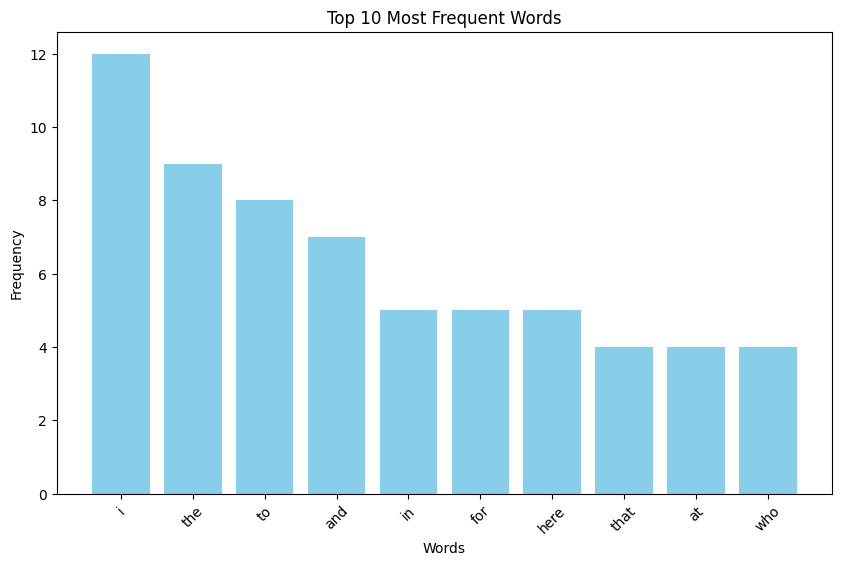

In [ ]:
# step 3 slecting the most frequent words

import heapq
import matplotlib.pyplot as plt

freq_words = heapq.nlargest(10, word2count, key=word2count.get)
print(f"Top 10 frequent words: {freq_words}")
top_words = sorted(word2count.items(), key=lambda x: x[1],
reverse=True)[:10]

words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

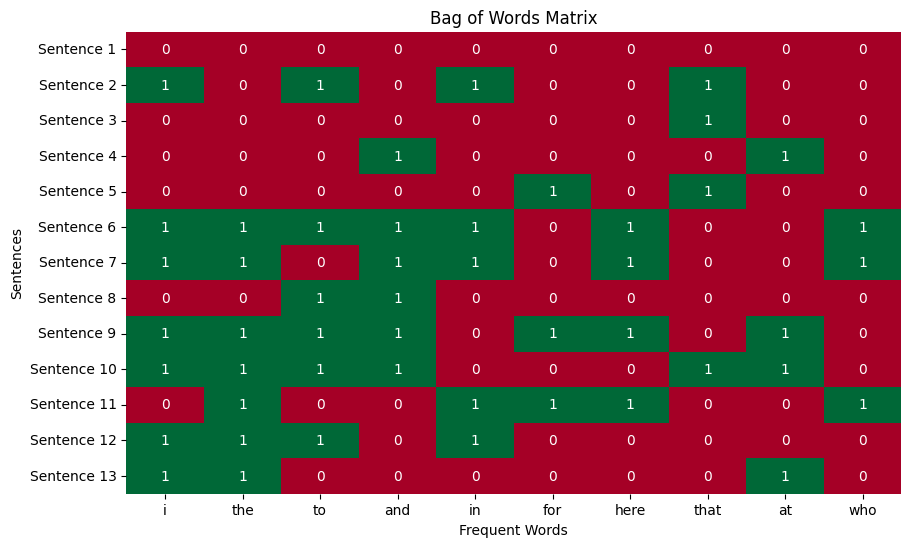

In [ ]:
# plotting a word matrix
X = []
for data in dataset:
 vector = []
 words_in_data = nltk.word_tokenize(data)
 for word in freq_words:
  if word in nltk.word_tokenize(data):
     vector.append(1)
  else:
     vector.append(0)
 X.append(vector)
X = np.asarray(X)


plt.figure(figsize=(10, 6))
sns.heatmap(X, cmap='RdYlGn', cbar=False, annot=True, fmt="d",
xticklabels=freq_words, yticklabels=[f"Sentence {i+1}" for i in
range(len(dataset))])
plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

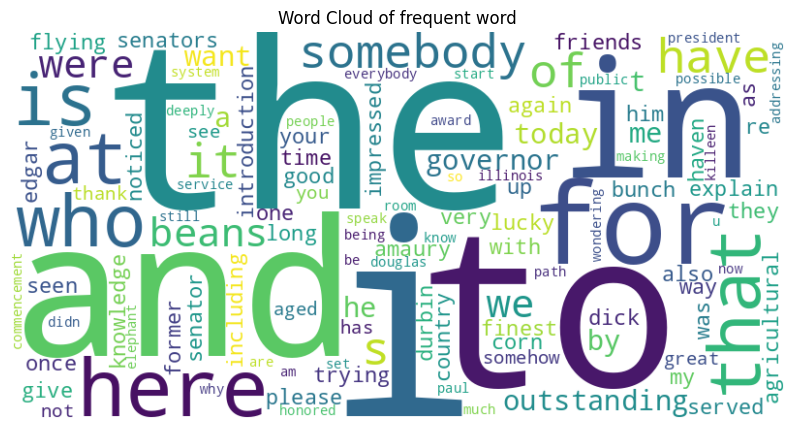

In [ ]:
# visualising the word frequency with word cloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word2count)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of frequent word')
plt.show()


In [ ]:
# Bag of words using Scikit-Learn:
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "I love NLP",
    "I love Python",
    "Python loves AI"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['ai' 'love' 'loves' 'nlp' 'python']
[[0 1 0 1 0]
 [0 1 0 0 1]
 [1 0 1 0 1]]


# TF-IDF (Term Frequency-Inverse Document Frequency)

In [ ]:
#step 1 :import liabraries
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
d1 =  "The cat sat on the mat."
d2 = "The dog played in the park."
d3 = "Cats and dogs are great pets."
string = [d1,d2,d3]

In [ ]:
# step-3: get tf - idf values
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(string)

In [ ]:
# Step 4: Display IDF values
print('\nidf values:')
for ele1, ele2 in zip(tfidf.get_feature_names_out(), tfidf.idf_):
  print(ele1, ':', ele2)


idf values:
and : 1.6931471805599454
are : 1.6931471805599454
cat : 1.6931471805599454
cats : 1.6931471805599454
dog : 1.6931471805599454
dogs : 1.6931471805599454
great : 1.6931471805599454
in : 1.6931471805599454
mat : 1.6931471805599454
on : 1.6931471805599454
park : 1.6931471805599454
pets : 1.6931471805599454
played : 1.6931471805599454
sat : 1.6931471805599454
the : 1.2876820724517808


In [ ]:
# Step 5: Display TF-IDF values along with indexing
print('\nWord indexes:')
print(tfidf.vocabulary_)
print('\ntf-idf value:')
print(result)
print('\ntf-idf values in matrix form:')
print(result.toarray())


Word indexes:
{'the': 14, 'cat': 2, 'sat': 13, 'on': 9, 'mat': 8, 'dog': 4, 'played': 12, 'in': 7, 'park': 10, 'cats': 3, 'and': 0, 'dogs': 5, 'are': 1, 'great': 6, 'pets': 11}

tf-idf value:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16 stored elements and shape (3, 15)>
  Coords	Values
  (0, 14)	0.6053485081062917
  (0, 2)	0.3979802707840827
  (0, 13)	0.3979802707840827
  (0, 9)	0.3979802707840827
  (0, 8)	0.3979802707840827
  (1, 14)	0.6053485081062917
  (1, 4)	0.3979802707840827
  (1, 12)	0.3979802707840827
  (1, 7)	0.3979802707840827
  (1, 10)	0.3979802707840827
  (2, 3)	0.4082482904638631
  (2, 0)	0.4082482904638631
  (2, 5)	0.4082482904638631
  (2, 1)	0.4082482904638631
  (2, 6)	0.4082482904638631
  (2, 11)	0.4082482904638631

tf-idf values in matrix form:
[[0.         0.         0.39798027 0.         0.         0.
  0.         0.         0.39798027 0.39798027 0.         0.
  0.         0.39798027 0.60534851]
 [0.         0.         0.         0.         0.39

In [ ]:
# TF-IDF using scikit learn

from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "I love NLP",
    "I love Machine Learning",
    "Machine Learning is amazing"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['amazing' 'is' 'learning' 'love' 'machine' 'nlp']
[[0.         0.         0.         0.60534851 0.         0.79596054]
 [0.         0.         0.57735027 0.57735027 0.57735027 0.        ]
 [0.5628291  0.5628291  0.42804604 0.         0.42804604 0.        ]]
